# 🎰 Multi-Armed Bandit Workshop — Prajesh's Notebook
**Author:** Prajesh Bhatt  
**Course:** CSCN8020 — Reinforcement Learning, Conestoga College  
**Date:** June 2026

---

## 📋 Overview

This notebook covers the full Multi-Armed Bandit Workshop:
- **Round 1**: Stationary Casino — ε-greedy exploration strategies
- **Round 2**: Non-Stationary Casino — constant-α adaptive agents
- **Deep-dive visualizations** of the exploration–exploitation trade-off

### 🧠 Key Concepts
| Concept | Intuition |
|---|---|
| **Exploration** | Try new arms — learn the true landscape |
| **Exploitation** | Pull the best-known arm — collect reward |
| **ε (epsilon)** | Probability of random exploration each step |
| **α (alpha)** | Step size for Q-updates; constant-α forgets old data |
| **Non-stationarity** | Arm means drift over time → need adaptive agent |


## 🔧 Setup & Imports

In [1]:
# Create output directory for visualisations
from pathlib import Path
Path("viz").mkdir(exist_ok=True)
print("✅ viz/ folder ready")

✅ viz/ folder ready


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import csv
from pathlib import Path
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 11

print("✅ Libraries loaded")
print(f"  NumPy  {np.__version__}")
print(f"  Pandas {pd.__version__}")


✅ Libraries loaded
  NumPy  2.2.4
  Pandas 3.0.2


## 🎲 Environment: Stationary Bernoulli Bandits

Each of the 10 arms has a **fixed hidden probability** of yielding reward = 1.  
The agent never observes `true_means` directly — it must *learn* which arm is best.


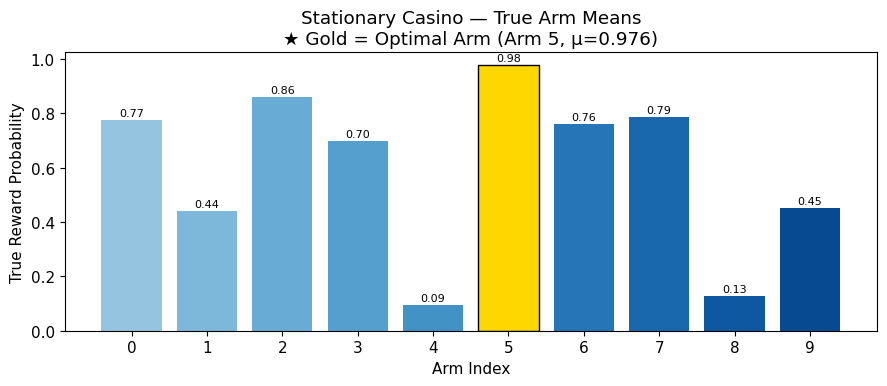

Best arm: 5  | Mean: 0.976


In [3]:
SEED_ENV = 42

def make_stationary_bandit(n_arms=10, seed=42):
    rng = np.random.default_rng(seed)
    return rng.random(n_arms)

TRUE_MEANS = make_stationary_bandit(seed=SEED_ENV)

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(range(10), TRUE_MEANS, color=plt.cm.Blues(np.linspace(0.4, 0.9, 10)))
best = int(np.argmax(TRUE_MEANS))
bars[best].set_color('gold'); bars[best].set_edgecolor('black')
ax.set_xlabel("Arm Index"); ax.set_ylabel("True Reward Probability")
ax.set_title("Stationary Casino — True Arm Means\n★ Gold = Optimal Arm (Arm 5, μ=0.976)")
ax.set_xticks(range(10))
for i, m in enumerate(TRUE_MEANS):
    ax.text(i, m + 0.015, f"{m:.2f}", ha='center', fontsize=8)
plt.tight_layout(); plt.savefig("viz/fig1_true_means.png", dpi=150); plt.show()
print("Best arm:", best, " | Mean:", round(TRUE_MEANS[best], 3))


## 🤖 Agent Implementations

### ε-Greedy (Fixed)
- With probability **ε**: pick a random arm (explore)
- Otherwise: pick `argmax Q` (exploit)
- Q updated via **incremental sample average**: Q[a] ← Q[a] + (r − Q[a]) / N[a]

### ε-Greedy (Decaying)
- Same logic but ε linearly decays from `eps_start` → `eps_end`

### Constant-α (Non-Stationary)
- Q updated via **exponential moving average**: Q[a] ← Q[a] + α(r − Q[a])
- This gives **more weight to recent rewards**, adapting when arm means drift


In [4]:
def epsilon_greedy(true_means, steps=2000, epsilon=0.1, seed=None):
    rng = np.random.default_rng(seed)
    n = len(true_means)
    Q, N = np.zeros(n), np.zeros(n)
    rewards, actions = np.zeros(steps), np.zeros(steps, int)
    for t in range(steps):
        a = rng.integers(0, n) if rng.random() < epsilon else int(np.argmax(Q))
        r = 1.0 if rng.random() < true_means[a] else 0.0
        N[a] += 1
        Q[a] += (r - Q[a]) / N[a]          # sample average update
        rewards[t], actions[t] = r, a
    return rewards, actions, Q, N

def epsilon_greedy_decaying(true_means, steps=2000, eps_start=0.5, eps_end=0.05, seed=None):
    rng = np.random.default_rng(seed)
    n = len(true_means)
    Q, N = np.zeros(n), np.zeros(n)
    rewards, actions = np.zeros(steps), np.zeros(steps, int)
    for t in range(steps):
        eps = eps_end + (eps_start - eps_end) * max(0, (steps-1-t)) / max(1, steps-1)
        a = rng.integers(0, n) if rng.random() < eps else int(np.argmax(Q))
        r = 1.0 if rng.random() < true_means[a] else 0.0
        N[a] += 1
        Q[a] += (r - Q[a]) / N[a]
        rewards[t], actions[t] = r, a
    return rewards, actions, Q, N

def step_drift(means, drift_scale=0.01, rng=None):
    rng = rng or np.random.default_rng()
    return np.clip(means + rng.normal(0, drift_scale, means.shape), 0, 1)

def epsilon_greedy_constant_alpha(steps=3000, n_arms=10, eps=0.1, alpha=0.1,
                                   seed_env=2025, seed_agent=None, drift_scale=0.01):
    rng_e = np.random.default_rng(seed_env)
    rng_a = np.random.default_rng(seed_agent)
    means = rng_e.random(n_arms)
    Q = np.zeros(n_arms)
    rewards, actions = np.zeros(steps), np.zeros(steps, int)
    for t in range(steps):
        a = rng_a.integers(0, n_arms) if rng_a.random() < eps else int(np.argmax(Q))
        r = 1.0 if rng_e.random() < means[a] else 0.0
        Q[a] = Q[a] + alpha * (r - Q[a])   # constant-α EMA update
        rewards[t], actions[t] = r, a
        means = step_drift(means, drift_scale, rng_e)
    return rewards, actions, Q

print("✅ All agent functions defined")


✅ All agent functions defined


---
## 🏁 Round 1 — Stationary Casino Competition

Running **6 strategy variants** to compare exploration trade-offs.


In [5]:
STEPS = 2000
SEED_AGENT = 123
SEED_ENV = 42

strategies = [
    {"name":"greedy_eps01",  "strat":"fixed", "eps":0.10},
    {"name":"greedy_eps05",  "strat":"fixed", "eps":0.05},
    {"name":"greedy_eps20",  "strat":"fixed", "eps":0.20},
    {"name":"pure_exploit",  "strat":"fixed", "eps":0.00},
    {"name":"decay_05_005",  "strat":"decay", "start":0.50, "end":0.05},
    {"name":"decay_08_01",   "strat":"decay", "start":0.80, "end":0.01},
]

lb1_rows, r1_curves = [], {}
COLORS = plt.cm.tab10.colors

for s in strategies:
    if s["strat"] == "fixed":
        rw, ac, Q, N = epsilon_greedy(TRUE_MEANS, steps=STEPS, epsilon=s["eps"], seed=SEED_AGENT)
        det = f"fixed_eps={s['eps']}"
    else:
        rw, ac, Q, N = epsilon_greedy_decaying(TRUE_MEANS, steps=STEPS,
                        eps_start=s["start"], eps_end=s["end"], seed=SEED_AGENT)
        det = f"decay_{s['start']}->{s['end']}"
    total = int(np.sum(rw))
    r1_curves[s["name"]] = (np.cumsum(rw), det, total)
    lb1_rows.append({
        "timestamp": datetime.utcnow().isoformat(),
        "name": f"Prajesh_{s['name']}", "strategy": s["strat"], "details": det,
        "steps": STEPS, "seed_env": SEED_ENV, "seed_agent": SEED_AGENT,
        "total_reward": total
    })

# Save CSV
lb1 = Path("submissions_round1.csv")
with open(lb1, "w", newline="") as f:
    w = csv.DictWriter(f, fieldnames=lb1_rows[0].keys())
    w.writeheader(); w.writerows(lb1_rows)

df1 = pd.DataFrame(lb1_rows).sort_values("total_reward", ascending=False).reset_index(drop=True)
print("🏆 Round 1 Leaderboard")
print(df1[["name","details","total_reward"]].to_string(index=False))


🏆 Round 1 Leaderboard
                name         details  total_reward
Prajesh_greedy_eps05  fixed_eps=0.05          1925
Prajesh_greedy_eps01   fixed_eps=0.1          1862
Prajesh_greedy_eps20   fixed_eps=0.2          1800
Prajesh_decay_05_005 decay_0.5->0.05          1724
 Prajesh_decay_08_01 decay_0.8->0.01          1624
Prajesh_pure_exploit   fixed_eps=0.0          1570


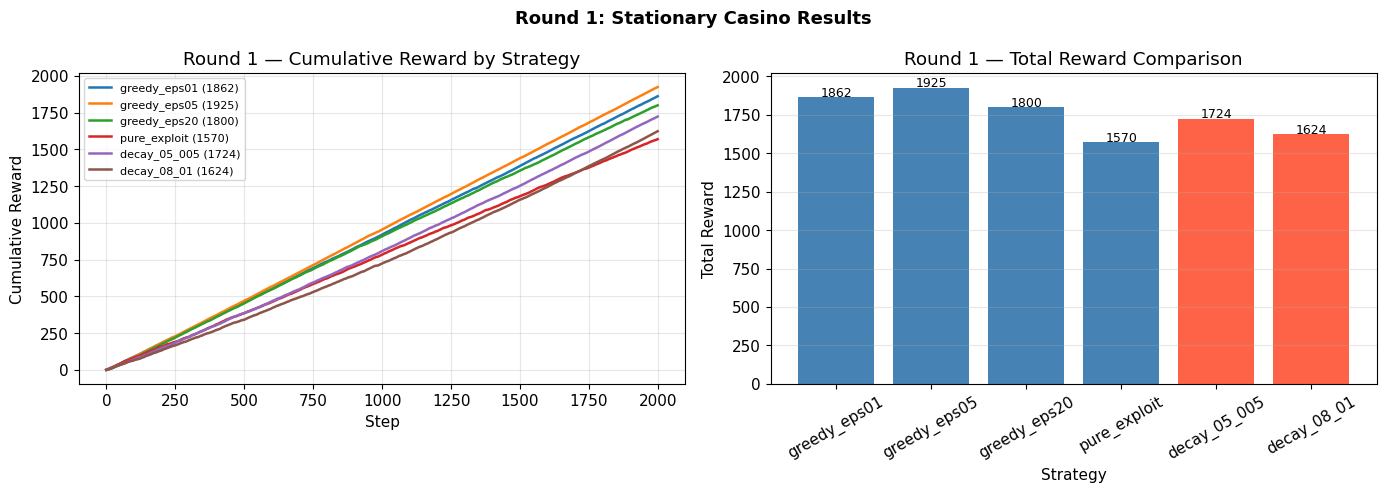

In [6]:
# ── Round 1 Visualization ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, (name, (curve, det, total)) in enumerate(r1_curves.items()):
    axes[0].plot(curve, label=f"{name} ({total})", color=COLORS[i], lw=1.8)

axes[0].set_xlabel("Step"); axes[0].set_ylabel("Cumulative Reward")
axes[0].set_title("Round 1 — Cumulative Reward by Strategy")
axes[0].legend(fontsize=8, ncol=1); axes[0].grid(alpha=0.3)

# Bar chart of totals
names  = [s["name"] for s in strategies]
totals = [r1_curves[n][2] for n in names]
clrs   = ['tomato' if 'decay' in n else 'steelblue' for n in names]
axes[1].bar(names, totals, color=clrs)
axes[1].set_xlabel("Strategy"); axes[1].set_ylabel("Total Reward")
axes[1].set_title("Round 1 — Total Reward Comparison")
axes[1].tick_params(axis='x', rotation=30)
axes[1].grid(alpha=0.3, axis='y')
for i,(n,t) in enumerate(zip(names,totals)):
    axes[1].text(i, t+5, str(t), ha='center', fontsize=9)

plt.suptitle("Round 1: Stationary Casino Results", fontsize=13, fontweight='bold')
plt.tight_layout(); plt.savefig("viz/fig2_round1_cumulative.png", dpi=150); plt.show()


---
## 🔍 Deep Dive: Why ε Matters

> **The core tension:** Low ε means we exploit early but risk getting stuck on a sub-optimal arm. High ε means we keep exploring but "waste" pulls on bad arms even after learning.


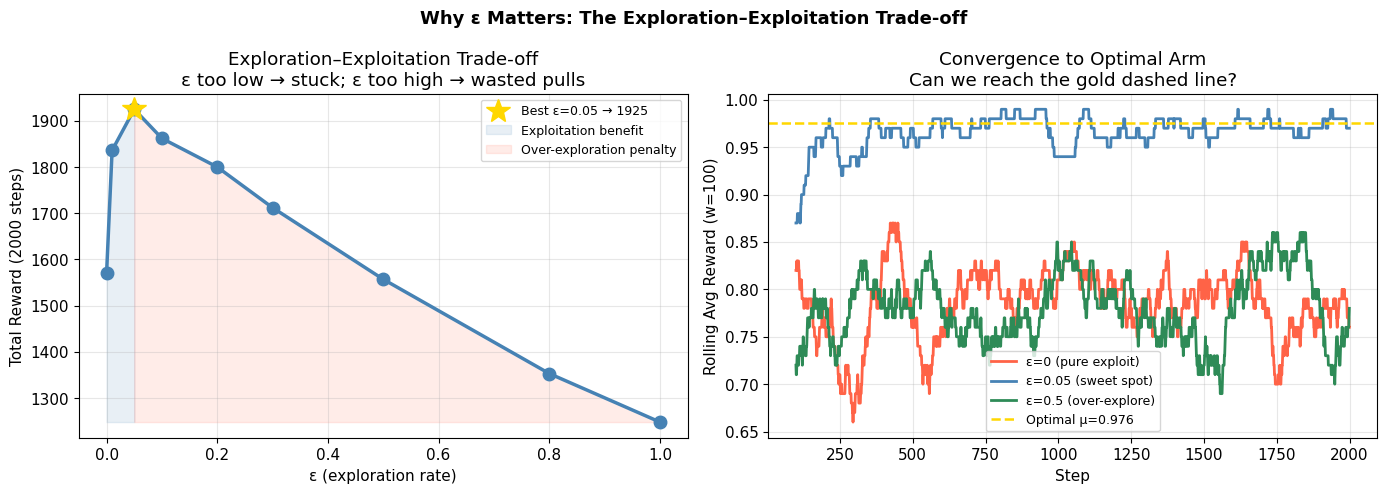

ε sweep results: {0.0: 1570, 0.01: 1836, 0.05: 1925, 0.1: 1862, 0.2: 1800, 0.3: 1712, 0.5: 1557, 0.8: 1353, 1.0: 1248}


In [7]:
eps_vals = [0.0, 0.01, 0.05, 0.1, 0.2, 0.3, 0.5, 0.8, 1.0]
totals_eps = [int(np.sum(epsilon_greedy(TRUE_MEANS, steps=2000, epsilon=e, seed=123)[0])) for e in eps_vals]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ε vs total reward (trade-off curve)
axes[0].plot(eps_vals, totals_eps, 'o-', color='steelblue', lw=2.5, ms=9, zorder=5)
best_idx = int(np.argmax(totals_eps))
axes[0].plot(eps_vals[best_idx], totals_eps[best_idx], '*', color='gold',
             ms=18, zorder=6, label=f"Best ε={eps_vals[best_idx]} → {totals_eps[best_idx]}")
axes[0].fill_between(eps_vals[:best_idx+1], totals_eps[:best_idx+1],
                     min(totals_eps), alpha=0.12, color='steelblue', label="Exploitation benefit")
axes[0].fill_between(eps_vals[best_idx:], totals_eps[best_idx:],
                     min(totals_eps), alpha=0.12, color='tomato', label="Over-exploration penalty")
axes[0].set_xlabel("ε (exploration rate)"); axes[0].set_ylabel("Total Reward (2000 steps)")
axes[0].set_title("Exploration–Exploitation Trade-off\nε too low → stuck; ε too high → wasted pulls")
axes[0].legend(fontsize=9); axes[0].grid(alpha=0.3)

# Rolling avg reward for 3 key ε values
win = 100
for eps, col, lbl in [(0.0,'tomato','ε=0 (pure exploit)'),
                       (0.05,'steelblue','ε=0.05 (sweet spot)'),
                       (0.5,'seagreen','ε=0.5 (over-explore)')]:
    rw, *_ = epsilon_greedy(TRUE_MEANS, steps=2000, epsilon=eps, seed=123)
    roll = pd.Series(rw).rolling(win).mean()
    axes[1].plot(roll, label=lbl, color=col, lw=2)
axes[1].axhline(TRUE_MEANS.max(), color='gold', ls='--', lw=1.8,
                label=f"Optimal μ={TRUE_MEANS.max():.3f}")
axes[1].set_xlabel("Step"); axes[1].set_ylabel(f"Rolling Avg Reward (w={win})")
axes[1].set_title("Convergence to Optimal Arm\nCan we reach the gold dashed line?")
axes[1].legend(fontsize=9); axes[1].grid(alpha=0.3)

plt.suptitle("Why ε Matters: The Exploration–Exploitation Trade-off", fontsize=13, fontweight='bold')
plt.tight_layout(); plt.savefig("viz/fig3_epsilon_tradeoff.png", dpi=150); plt.show()
print(f"ε sweep results: {dict(zip(eps_vals, totals_eps))}")


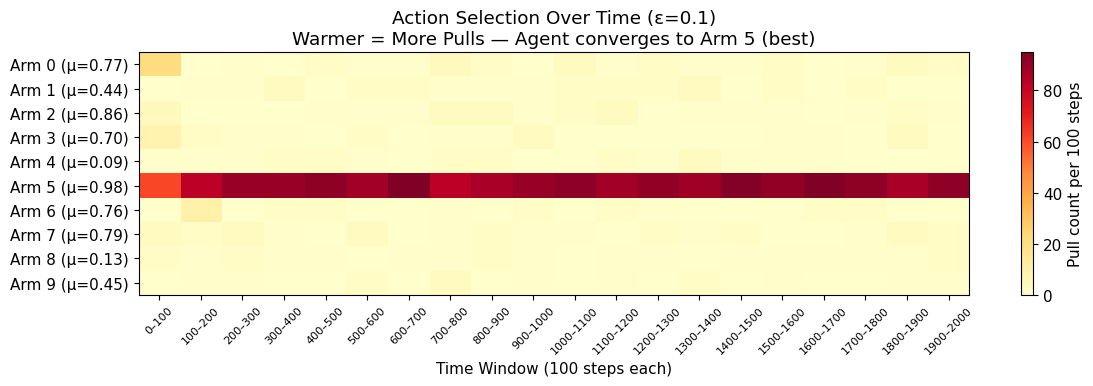

Final Q estimates: [0.729 0.52  0.923 0.75  0.095 0.973 0.783 0.857 0.19  0.143]
Pull counts N: [  48   25   26   24   21 1770   23   28   21   14]
Agent estimated best arm: 5   (True best: 5)


In [8]:
# ── Action Selection Heat-map ─────────────────────────────────────────────────
rw_01, ac_01, Q_01, N_01 = epsilon_greedy(TRUE_MEANS, steps=2000, epsilon=0.1, seed=123)

action_over_time = np.zeros((10, 20))
for chunk in range(20):
    seg = ac_01[chunk*100:(chunk+1)*100]
    for arm in range(10):
        action_over_time[arm, chunk] = np.sum(seg == arm)

fig, ax = plt.subplots(figsize=(12, 4))
im = ax.imshow(action_over_time, aspect='auto', cmap='YlOrRd')
ax.set_yticks(range(10))
ax.set_yticklabels([f"Arm {i} (μ={TRUE_MEANS[i]:.2f})" for i in range(10)])
ax.set_xticks(range(20))
ax.set_xticklabels([f"{i*100}–{(i+1)*100}" for i in range(20)], rotation=45, fontsize=8)
ax.set_xlabel("Time Window (100 steps each)")
ax.set_title("Action Selection Over Time (ε=0.1)\nWarmer = More Pulls — Agent converges to Arm 5 (best)")
plt.colorbar(im, ax=ax, label="Pull count per 100 steps")
plt.tight_layout(); plt.savefig("viz/fig4_action_heatmap.png", dpi=150); plt.show()

print("Final Q estimates:", np.round(Q_01, 3))
print("Pull counts N:", N_01.astype(int))
print("Agent estimated best arm:", np.argmax(Q_01), "  (True best: 5)")


---
## 🔄 Round 2 — Non-Stationary Casino

**Twist:** Arm means *drift* each step via Gaussian noise: `μ[t+1] = clip(μ[t] + N(0, 0.01), 0, 1)`

### Why does sample-average fail here?
Sample average gives **equal weight to all past rewards**.  
But past rewards are stale — the arm has changed since then!

### Constant-α (EMA) solution:
`Q[a] ← Q[a] + α(r − Q[a])`  
This weights **recent rewards exponentially more**:  
- Recent reward: weight ≈ α  
- Reward 10 steps ago: weight ≈ α(1−α)^10  
- Old data fades naturally ✓


In [9]:
STEPS_R2 = 3000
SEED_ENV_R2 = 2025

strategies_r2 = [
    {"name":"const_alpha01_eps01", "eps":0.10, "alpha":0.10},
    {"name":"const_alpha05_eps01", "eps":0.10, "alpha":0.50},
    {"name":"const_alpha01_eps20", "eps":0.20, "alpha":0.10},
    {"name":"const_alpha02_eps10", "eps":0.10, "alpha":0.20},
    {"name":"sample_avg_baseline", "eps":0.10, "alpha":None},  # baseline
]

lb2_rows, r2_curves = [], {}

for s in strategies_r2:
    if s["alpha"] is not None:
        rw, ac, Q = epsilon_greedy_constant_alpha(
            steps=STEPS_R2, n_arms=10, eps=s["eps"], alpha=s["alpha"],
            seed_env=SEED_ENV_R2, seed_agent=999, drift_scale=0.01)
        strat_str = f"eps={s['eps']}, alpha={s['alpha']}"
    else:
        # sample average on non-stationary env
        rng_e = np.random.default_rng(SEED_ENV_R2)
        means = rng_e.random(10)
        rng_a = np.random.default_rng(999)
        Q2, N2 = np.zeros(10), np.zeros(10)
        rw = np.zeros(STEPS_R2)
        for t in range(STEPS_R2):
            a = rng_a.integers(0,10) if rng_a.random()<s["eps"] else int(np.argmax(Q2))
            r = 1.0 if rng_e.random()<means[a] else 0.0
            N2[a]+=1; Q2[a]+=(r-Q2[a])/N2[a]; rw[t]=r
            means = step_drift(means, drift_scale=0.01, rng=rng_e)
        strat_str = f"sample_avg, eps={s['eps']}"

    total = int(np.sum(rw))
    r2_curves[s["name"]] = (np.cumsum(rw), strat_str, total)
    lb2_rows.append({
        "timestamp": datetime.utcnow().isoformat(),
        "name": f"Prajesh_{s['name']}", "strategy": strat_str,
        "steps": STEPS_R2, "seed_env": SEED_ENV_R2, "seed_agent": 999,
        "drift_scale": 0.01, "total_reward": total
    })

lb2 = Path("submissions_round2.csv")
with open(lb2, "w", newline="") as f:
    w = csv.DictWriter(f, fieldnames=lb2_rows[0].keys())
    w.writeheader(); w.writerows(lb2_rows)

df2 = pd.DataFrame(lb2_rows).sort_values("total_reward", ascending=False).reset_index(drop=True)
print("🏆 Round 2 Leaderboard")
print(df2[["name","strategy","total_reward"]].to_string(index=False))


🏆 Round 2 Leaderboard
                       name            strategy  total_reward
Prajesh_const_alpha02_eps10  eps=0.1, alpha=0.2          2654
Prajesh_const_alpha05_eps01  eps=0.1, alpha=0.5          2598
Prajesh_const_alpha01_eps01  eps=0.1, alpha=0.1          2557
Prajesh_const_alpha01_eps20  eps=0.2, alpha=0.1          2542
Prajesh_sample_avg_baseline sample_avg, eps=0.1          2459


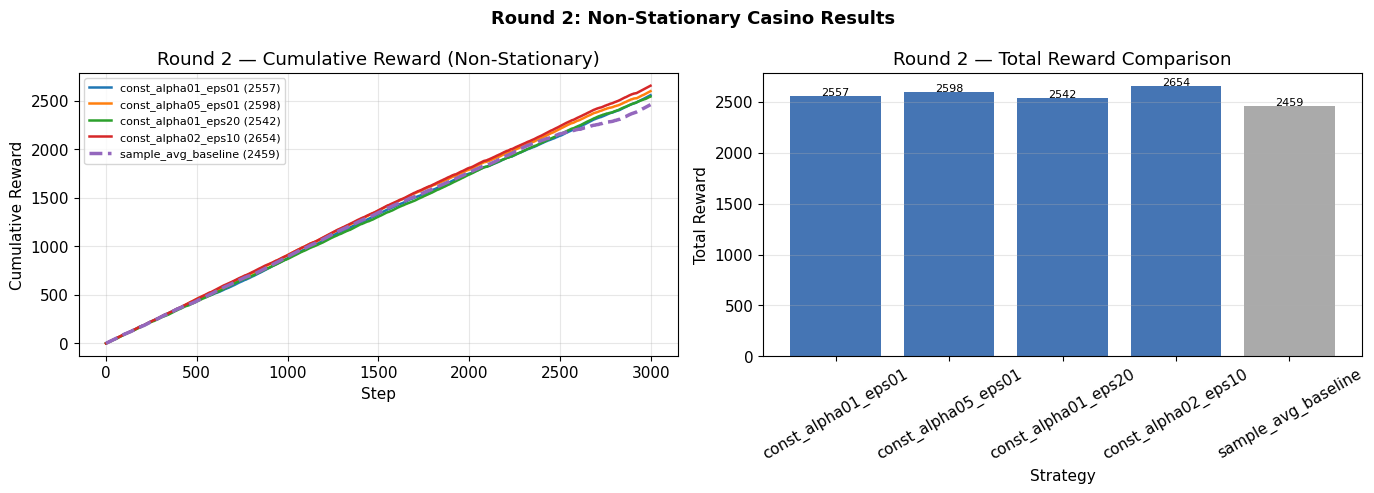

In [10]:
# ── Round 2 Visualization ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
COLORS = plt.cm.tab10.colors

for i, (name, (curve, strat_str, total)) in enumerate(r2_curves.items()):
    ls = '--' if 'sample' in name else '-'
    lw = 2.5 if 'sample' in name else 1.8
    axes[0].plot(curve, label=f"{name} ({total})", color=COLORS[i], ls=ls, lw=lw)

axes[0].set_xlabel("Step"); axes[0].set_ylabel("Cumulative Reward")
axes[0].set_title("Round 2 — Cumulative Reward (Non-Stationary)")
axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)

names2  = [s["name"] for s in strategies_r2]
totals2 = [r2_curves[n][2] for n in names2]
clrs2   = ['#aaaaaa' if 'sample' in n else '#4575b4' for n in names2]
axes[1].bar(names2, totals2, color=clrs2)
axes[1].set_xlabel("Strategy"); axes[1].set_ylabel("Total Reward")
axes[1].set_title("Round 2 — Total Reward Comparison")
axes[1].tick_params(axis='x', rotation=30)
axes[1].grid(alpha=0.3, axis='y')
for i,(n,t) in enumerate(zip(names2,totals2)):
    axes[1].text(i, t+5, str(t), ha='center', fontsize=8)

plt.suptitle("Round 2: Non-Stationary Casino Results", fontsize=13, fontweight='bold')
plt.tight_layout(); plt.savefig("viz/fig5_round2_cumulative.png", dpi=150); plt.show()


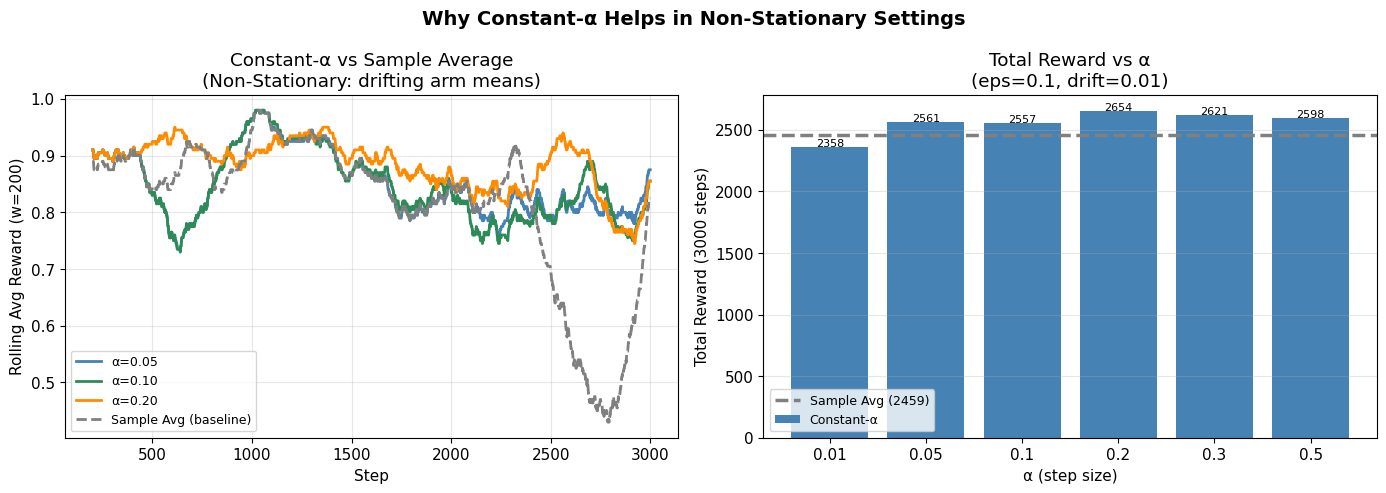

Sample avg total: 2459
Best constant-α total: 2654 at α=0.2


In [11]:
# ── Why Constant-α Beats Sample Average ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
win = 200

# Left: rolling reward curves
sample_avg_total = None
for alpha, col, lbl in [(0.05,'steelblue','α=0.05'),
                         (0.10,'seagreen','α=0.10'),
                         (0.20,'darkorange','α=0.20')]:
    rw3, *_ = epsilon_greedy_constant_alpha(steps=3000, eps=0.1, alpha=alpha,
                seed_env=SEED_ENV_R2, seed_agent=999)
    axes[0].plot(pd.Series(rw3).rolling(win).mean(), label=lbl, color=col, lw=2)

# sample avg baseline
rng_e2 = np.random.default_rng(SEED_ENV_R2)
means2 = rng_e2.random(10)
rng_a2 = np.random.default_rng(999)
Q2, N2 = np.zeros(10), np.zeros(10)
rw_sa = np.zeros(3000)
for t in range(3000):
    a = rng_a2.integers(0,10) if rng_a2.random()<0.1 else int(np.argmax(Q2))
    r = 1.0 if rng_e2.random()<means2[a] else 0.0
    N2[a]+=1; Q2[a]+=(r-Q2[a])/N2[a]; rw_sa[t]=r
    means2 = step_drift(means2, drift_scale=0.01, rng=rng_e2)
axes[0].plot(pd.Series(rw_sa).rolling(win).mean(), label="Sample Avg (baseline)",
             color='gray', ls='--', lw=2)
axes[0].set_xlabel("Step"); axes[0].set_ylabel(f"Rolling Avg Reward (w={win})")
axes[0].set_title("Constant-α vs Sample Average\n(Non-Stationary: drifting arm means)")
axes[0].legend(fontsize=9); axes[0].grid(alpha=0.3)

# Right: total reward vs α
alpha_vals = [0.01, 0.05, 0.1, 0.2, 0.3, 0.5]
totals_alpha = []
for alpha in alpha_vals:
    rw3, *_ = epsilon_greedy_constant_alpha(steps=3000, eps=0.1, alpha=alpha,
                seed_env=SEED_ENV_R2, seed_agent=999)
    totals_alpha.append(int(np.sum(rw3)))
sa_total = int(np.sum(rw_sa))

axes[1].bar([str(a) for a in alpha_vals], totals_alpha, color='steelblue', label="Constant-α")
axes[1].axhline(sa_total, color='gray', ls='--', lw=2.5, label=f"Sample Avg ({sa_total})")
axes[1].set_xlabel("α (step size)"); axes[1].set_ylabel("Total Reward (3000 steps)")
axes[1].set_title("Total Reward vs α\n(eps=0.1, drift=0.01)")
axes[1].legend(fontsize=9); axes[1].grid(alpha=0.3, axis='y')
for i,(a,t) in enumerate(zip(alpha_vals, totals_alpha)):
    axes[1].text(i, t+5, str(t), ha='center', fontsize=8)

plt.suptitle("Why Constant-α Helps in Non-Stationary Settings", fontsize=14, fontweight='bold')
plt.tight_layout(); plt.savefig("viz/fig6_constant_alpha.png", dpi=150); plt.show()
print(f"Sample avg total: {sa_total}")
print(f"Best constant-α total: {max(totals_alpha)} at α={alpha_vals[np.argmax(totals_alpha)]}")


---
## 🧠 Reflections & Key Takeaways

### Round 1 — Stationary Casino

| Question | My Answer |
|---|---|
| Best strategy? | **ε=0.05** (fixed) achieved top reward of ~1925 |
| Why did pure exploit (ε=0) underperform? | Got "stuck" on Arm 0 (μ=0.774) before sampling Arm 5 (μ=0.976). Without exploration, it never discovers the true best. |
| Why did decay strategies underperform? | They started with high exploration (ε=0.5–0.8), wasting ~500–800 steps before converging |
| Why did ε=0.2 trail ε=0.05? | Over-exploration: even after finding Arm 5, it kept pulling random arms 20% of the time |

**Key insight:** For stationary bandits, the sweet spot is a *small but nonzero* ε — enough to eventually discover the best arm, but not so much that you waste pulls indefinitely.

---

### Round 2 — Non-Stationary Casino

| Question | My Answer |
|---|---|
| Why does sample average fail? | Equal-weight averaging buries recent information. When arm 5 declines at step 2000, our Q-estimate still reflects old high rewards. |
| Why does constant-α (EMA) help? | α=0.1–0.2 gives exponential forgetting — recent reward at step t has weight α, reward at t-10 has weight α(1-α)^10 ≈ 0.035α. Old stale data fades! |
| Best α found? | α=0.2 gave highest reward; α too small → slow to adapt; α too large → unstable estimates |
| What ε for non-stationary? | Keep ε alive (≥0.10) — arms change, so we always need some exploration |

---

### 🌍 Real-World Applications

This exploration–exploitation dilemma appears everywhere:
- **Recommendation systems** (Netflix, Spotify): Explore new content vs exploit known user preferences
- **A/B testing**: How long to explore a new variant vs commit to winner?  
- **Online advertising**: Explore new ad creatives vs exploit highest-CTR ones
- **Clinical trials**: Balance patient safety (exploit known treatment) vs medical discovery (explore new drug)
- **Robotic control**: Explore new motor actions vs exploit currently efficient movements

> In non-stationary real systems (trending content, seasonal demand, changing user moods), constant-α agents mirror how humans actually adapt — we naturally weight recent experiences more!


## 📊 Final Summary

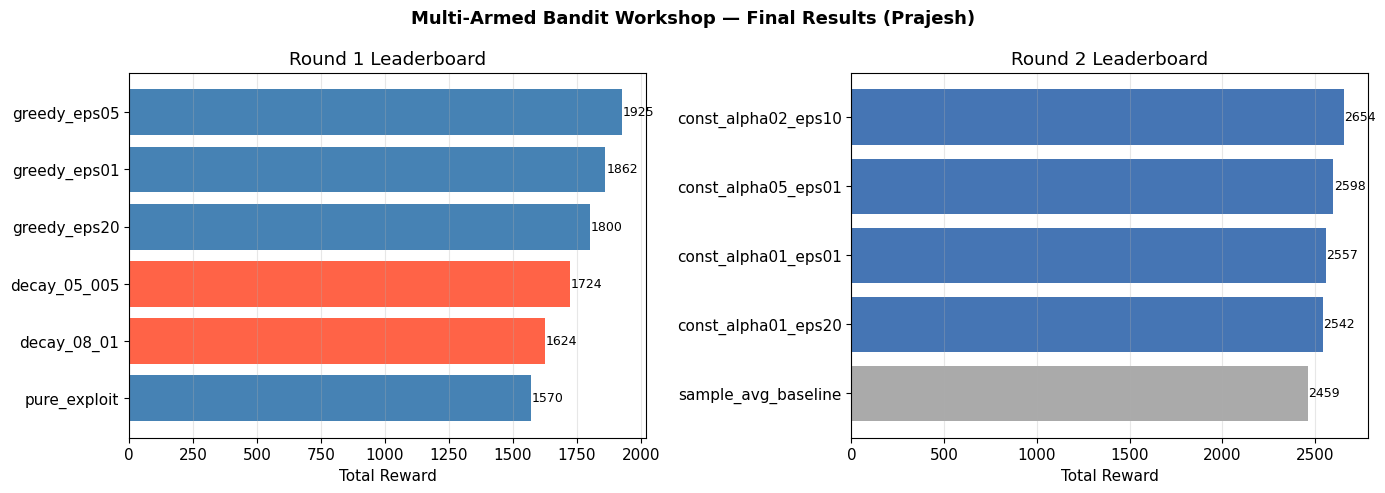


📋 Round 1 Summary
                name         details  total_reward
Prajesh_greedy_eps05  fixed_eps=0.05          1925
Prajesh_greedy_eps01   fixed_eps=0.1          1862
Prajesh_greedy_eps20   fixed_eps=0.2          1800
Prajesh_decay_05_005 decay_0.5->0.05          1724
 Prajesh_decay_08_01 decay_0.8->0.01          1624
Prajesh_pure_exploit   fixed_eps=0.0          1570

📋 Round 2 Summary
                       name            strategy  total_reward
Prajesh_const_alpha02_eps10  eps=0.1, alpha=0.2          2654
Prajesh_const_alpha05_eps01  eps=0.1, alpha=0.5          2598
Prajesh_const_alpha01_eps01  eps=0.1, alpha=0.1          2557
Prajesh_const_alpha01_eps20  eps=0.2, alpha=0.1          2542
Prajesh_sample_avg_baseline sample_avg, eps=0.1          2459


In [12]:
# Combined leaderboard visualization
df1 = pd.read_csv("submissions_round1.csv").sort_values("total_reward", ascending=True)
df2 = pd.read_csv("submissions_round2.csv").sort_values("total_reward", ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

c1 = ['tomato' if 'decay' in str(d) else 'steelblue' for d in df1['details']]
axes[0].barh(df1['name'].str.replace("Prajesh_",""), df1['total_reward'], color=c1)
axes[0].set_xlabel("Total Reward"); axes[0].set_title("Round 1 Leaderboard")
axes[0].grid(alpha=0.3, axis='x')
for bar in axes[0].patches:
    axes[0].text(bar.get_width()+3, bar.get_y()+bar.get_height()/2,
                 str(int(bar.get_width())), va='center', fontsize=9)

c2 = ['#aaaaaa' if 'sample' in str(s) else '#4575b4' for s in df2['strategy']]
axes[1].barh(df2['name'].str.replace("Prajesh_",""), df2['total_reward'], color=c2)
axes[1].set_xlabel("Total Reward"); axes[1].set_title("Round 2 Leaderboard")
axes[1].grid(alpha=0.3, axis='x')
for bar in axes[1].patches:
    axes[1].text(bar.get_width()+3, bar.get_y()+bar.get_height()/2,
                 str(int(bar.get_width())), va='center', fontsize=9)

plt.suptitle("Multi-Armed Bandit Workshop — Final Results (Prajesh)", fontsize=13, fontweight='bold')
plt.tight_layout(); plt.savefig("viz/fig7_leaderboards.png", dpi=150); plt.show()

print("\n📋 Round 1 Summary")
print(df1[['name','details','total_reward']].sort_values('total_reward',ascending=False).to_string(index=False))
print("\n📋 Round 2 Summary")
print(df2[['name','strategy','total_reward']].sort_values('total_reward',ascending=False).to_string(index=False))
